
--- Shape of Dataset ---
(1987, 10)

--- Column Names ---
['Unnamed:_0', 'Age', 'Employment_Type', 'GraduateOrNot', 'AnnualIncome', 'FamilyMembers', 'ChronicDiseases', 'FrequentFlyer', 'EverTravelledAbroad', 'TravelInsurance']

--- Missing Values ---
Unnamed:_0             0
Age                    0
Employment_Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

--- First 5 Rows ---
   Unnamed:_0  Age               Employment_Type GraduateOrNot  AnnualIncome  \
0           0   31             Government Sector           Yes        400000   
1           1   31  Private Sector/Self Employed           Yes       1250000   
2           2   34  Private Sector/Self Employed           Yes        500000   
3           3   28  Private Sector/Self Employed           Yes        700000   
4           4   28  Private Sector/Self Employed           Yes 

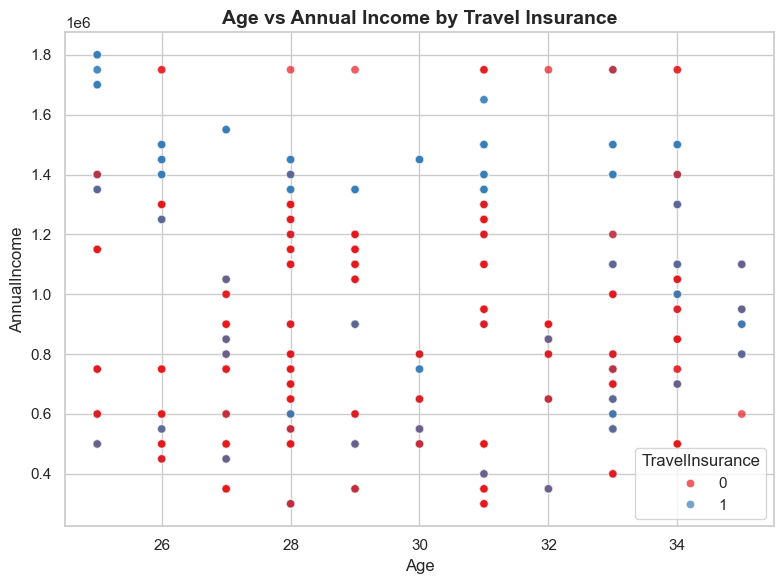

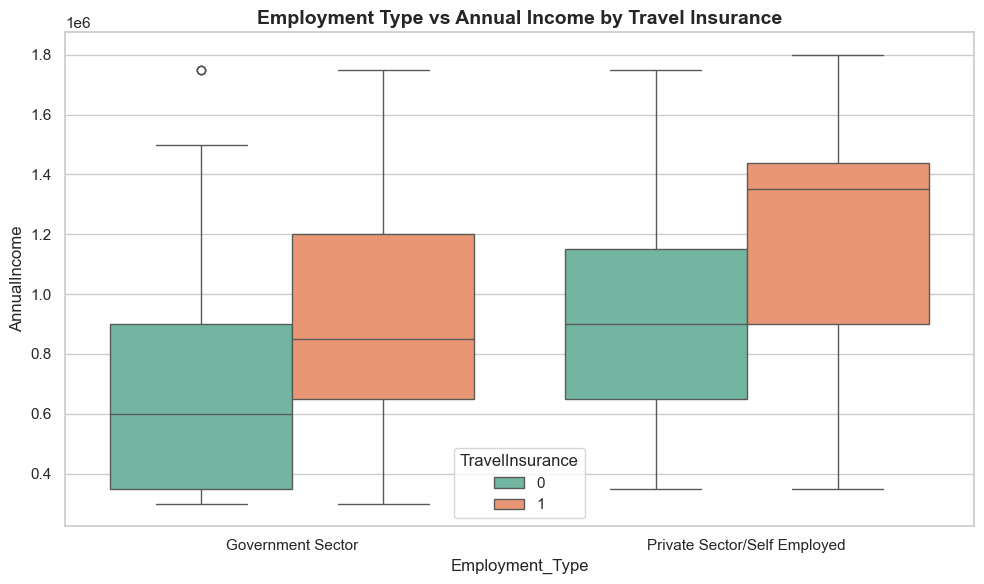

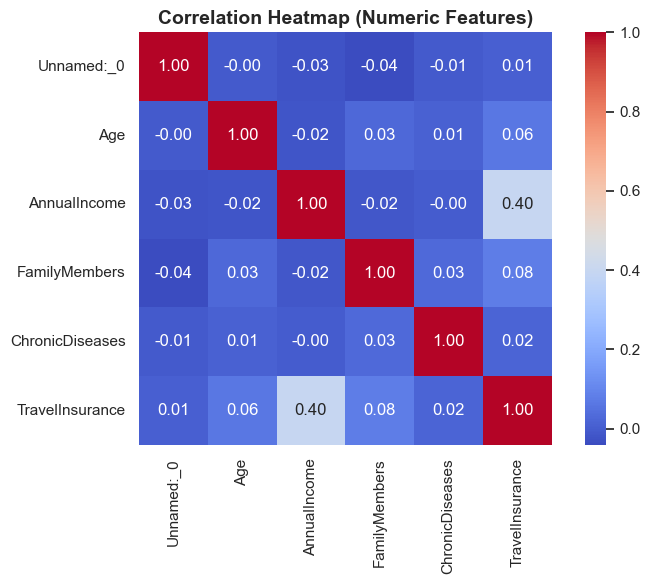

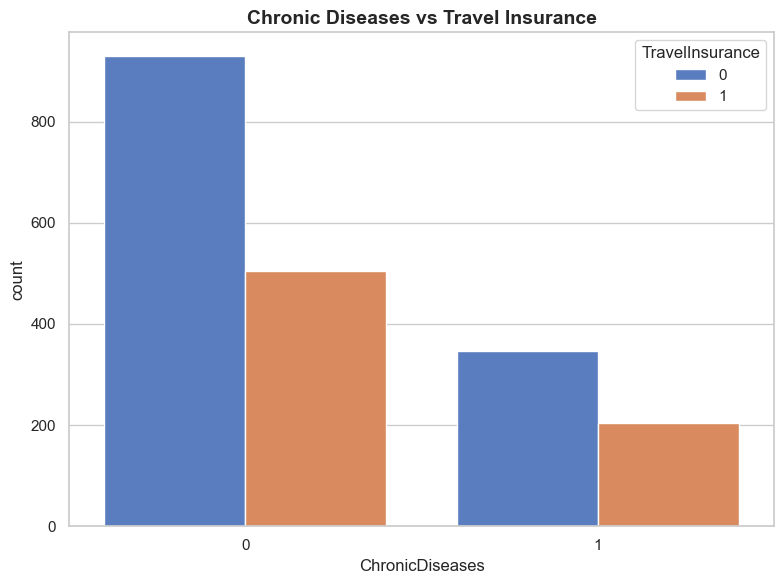

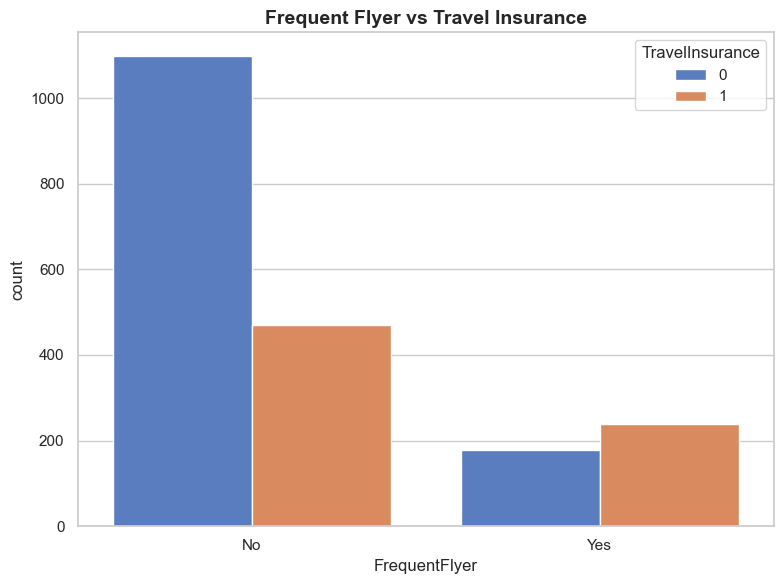

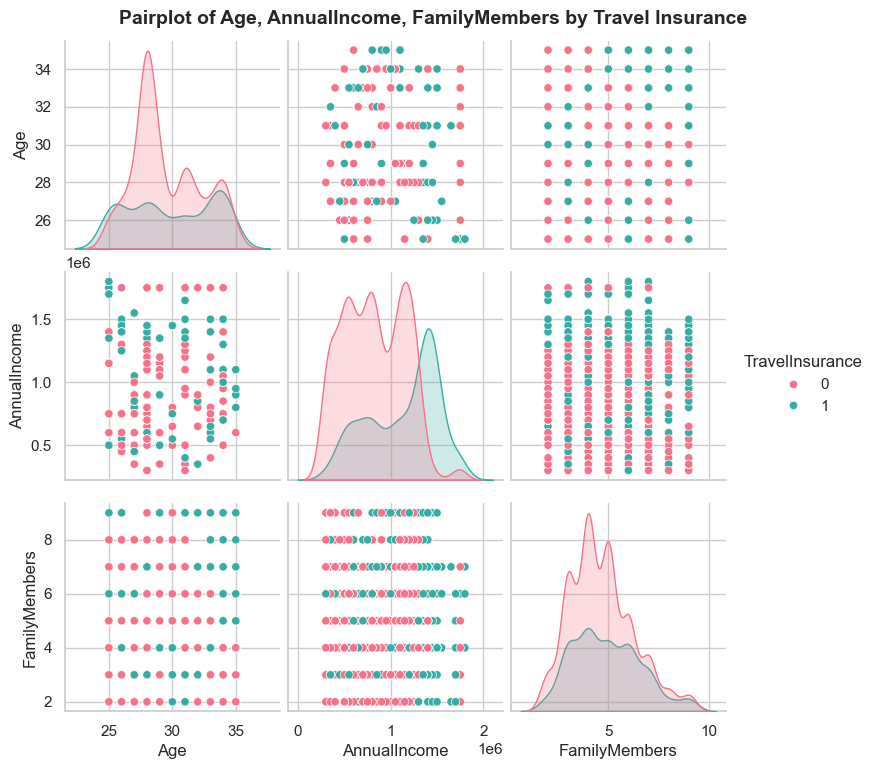

In [1]:
# ===============================
# EDA + Multivariate Visualizations (Insurance Dataset)
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv(r"C:/Users/swathi/Insurance.csv")

# Clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("-", "_")

# -------------------------------
# Global Plot Style
# -------------------------------
sns.set_theme(style="whitegrid")

# Folder to save images
save_path = "Insurance_EDA_Outputs"
os.makedirs(save_path, exist_ok=True)

def show_and_save(name):
    """Helper function to save and show plots"""
    plt.tight_layout()
    plt.savefig(f"{save_path}/{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

# -------------------------------
# 1. Basic Info
# -------------------------------
print("\n--- Shape of Dataset ---")
print(df.shape)

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- First 5 Rows ---")
print(df.head())

# -------------------------------
# 2. Descriptive Statistics
# -------------------------------
print("\n--- Statistical Summary ---")
print(df.describe(include="all"))

# =====================================================
# MULTIVARIATE VISUALIZATIONS
# =====================================================

# 1. Age vs Annual Income by Travel Insurance
plt.figure(figsize=(8,6))
sns.scatterplot(x="Age", y="AnnualIncome", hue="TravelInsurance", data=df, alpha=0.7, palette="Set1")
plt.title("Age vs Annual Income by Travel Insurance", fontsize=14, weight="bold")
show_and_save("Age_vs_Income_TravelInsurance")

# 2. Employment Type vs Income by Travel Insurance
plt.figure(figsize=(10,6))
sns.boxplot(x="Employment_Type", y="AnnualIncome", hue="TravelInsurance", data=df, palette="Set2")
plt.title("Employment Type vs Annual Income by Travel Insurance", fontsize=14, weight="bold")
show_and_save("Employment_vs_Income_TravelInsurance")

# 3. Correlation Heatmap (numeric features only)
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", cbar=True, square=True)
plt.title("Correlation Heatmap (Numeric Features)", fontsize=14, weight="bold")
show_and_save("Correlation_Heatmap")

# 4. Chronic Diseases vs Travel Insurance
plt.figure(figsize=(8,6))
sns.countplot(x="ChronicDiseases", hue="TravelInsurance", data=df, palette="muted")
plt.title("Chronic Diseases vs Travel Insurance", fontsize=14, weight="bold")
show_and_save("ChronicDiseases_vs_TravelInsurance")

# 5. Frequent Flyer vs Travel Insurance
plt.figure(figsize=(8,6))
sns.countplot(x="FrequentFlyer", hue="TravelInsurance", data=df, palette="muted")
plt.title("Frequent Flyer vs Travel Insurance", fontsize=14, weight="bold")
show_and_save("FrequentFlyer_vs_TravelInsurance")

# 6. Pairplot of Key Features
sns.pairplot(df, vars=["Age", "AnnualIncome", "FamilyMembers"], hue="TravelInsurance", palette="husl", diag_kind="kde")
plt.suptitle("Pairplot of Age, AnnualIncome, FamilyMembers by Travel Insurance", y=1.02, fontsize=14, weight="bold")
plt.savefig(f"{save_path}/Pairplot_KeyFeatures.png", dpi=300, bbox_inches="tight")
plt.show()